# 21. Integrasi dataset Bite2Text ke `data/view5`

Dataset baru `Bite2Text` (di `~/Downloads/Bite2Text`): 997 folder pasien, tiap folder punya
`intraoral-photo/intraoral_1.jpg` ... `intraoral_5.jpg`. **Tidak ada split train/val/test
bawaan** dan tidak ada kode angka di nama file seperti OMNI, jadi urutan 1-5 perlu diverifikasi
dulu sebelum dipakai.

Dari sampling awal (2 pasien), polanya kelihatan konsisten:

| index | hipotesis view | retractor? |
|---|---|---|
| 1 | frontal | ya |
| 2 | lateral (kanan ATAU kiri — belum pasti) | tidak |
| 3 | lateral (sisi satunya) | tidak |
| 4 | mandibular (lewat mirror) | tidak relevan |
| 5 | maxillary (lewat mirror) | tidak relevan |

Foto lateral di dataset ini **asli tanpa retractor** — bukan hasil augmentasi — jadi berharga
sebagai data evaluasi utk fix retractor-bug di notebook 17/18.

Langkah notebook ini:
1. Verifikasi index -> view (terutama kanan vs kiri di index 2/3) — visual, sampel beberapa pasien
2. Filter folder yang lengkap 5 foto
3. Split per pasien (50% train / 25% val / 25% test, seed tetap) -> copy ke `data/view5/{split}/{view}/`
   dengan prefix `bite2text_` di nama file biar tidak bentrok dengan file OMNI yang sudah ada

> **PENTING**: sel verifikasi (bagian 1) harus dicek visual dulu satu-satu sebelum lanjut ke
> bagian 2/3. Kalau index 2/3 ternyata kebalik dari hipotesis, ubah `INDEX_MAP` di sel berikut.

In [1]:
import os, random, shutil
from glob import glob
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image

BITE2TEXT_DIR = os.path.expanduser('~/Downloads/Bite2Text')
PROJECT_ROOT = os.path.expanduser('~/IOTN-AC')
OUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'view5')
SPLITS = ['train', 'val', 'test']
SPLIT_RATIO = {'train': 0.50, 'val': 0.25, 'test': 0.25}
SEED = 42
PREFIX = 'bite2text'

assert os.path.isdir(BITE2TEXT_DIR), f'Folder tidak ditemukan: {BITE2TEXT_DIR}'

# --- HIPOTESIS mapping index (1-5) -> nama view. Index 2 vs 3 (kanan/kiri) BELUM pasti,
# ubah di sini kalau hasil verifikasi visual di bawah menunjukkan kebalikannya. ---
INDEX_MAP = {
    '1': 'frontal',
    '2': 'lateral_kanan',
    '3': 'lateral_kiri',
    '4': 'mandibular',
    '5': 'maxillary',
}
print('BITE2TEXT_DIR:', BITE2TEXT_DIR)
print('OUT_DIR      :', OUT_DIR)

BITE2TEXT_DIR: /Users/rdrusdiati/Downloads/Bite2Text
OUT_DIR      : /Users/rdrusdiati/IOTN-AC/data/view5


## 1. Verifikasi index -> view (visual)

Tampilkan kelima foto dari beberapa pasien contoh berdampingan. Cek terutama index 2 vs 3:
mana yang benar-benar sisi kanan pasien, mana kiri (patokan: sisi kanan pasien = sisi kiri kita
kalau difoto berhadapan langsung dari depan, sama seperti cara baca foto frontal biasa).

In [2]:
def folder_pasien():
    """Semua folder pasien (nama diawali 'F') yang punya subfolder intraoral-photo."""
    out = []
    for nama in sorted(os.listdir(BITE2TEXT_DIR)):
        p = os.path.join(BITE2TEXT_DIR, nama, 'intraoral-photo')
        if nama.startswith('F') and os.path.isdir(p):
            out.append(nama)
    return out

def foto_lengkap(pasien_id):
    """Path kelima foto standar intraoral_1..5.jpg untuk satu pasien, atau None kalau tidak
    lengkap. File tambahan seperti intraoral-photo_XXXX.png (raw capture leftover) diabaikan."""
    d = os.path.join(BITE2TEXT_DIR, pasien_id, 'intraoral-photo')
    files = {}
    for k in INDEX_MAP:
        p = os.path.join(d, f'intraoral_{k}.jpg')
        if os.path.exists(p):
            files[k] = p
    return files if len(files) == 5 else None

PASIEN_SEMUA = folder_pasien()
print(f'Total folder pasien: {len(PASIEN_SEMUA)}')

Total folder pasien: 997


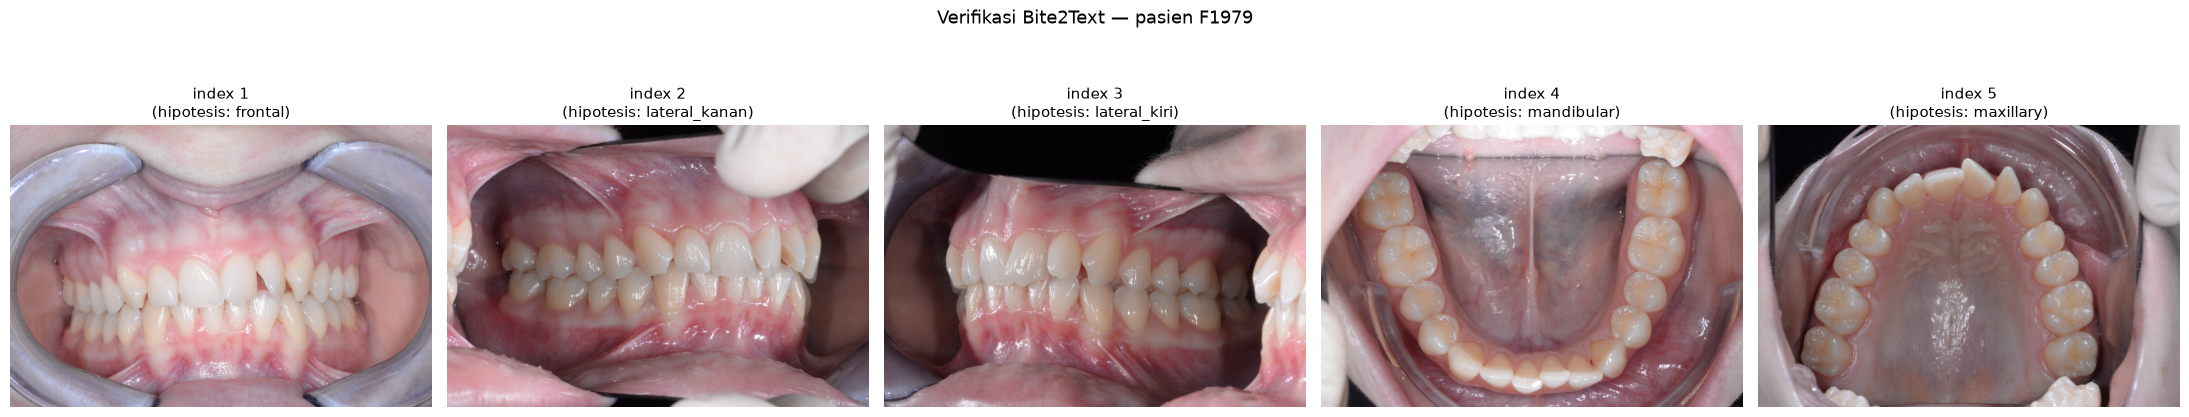

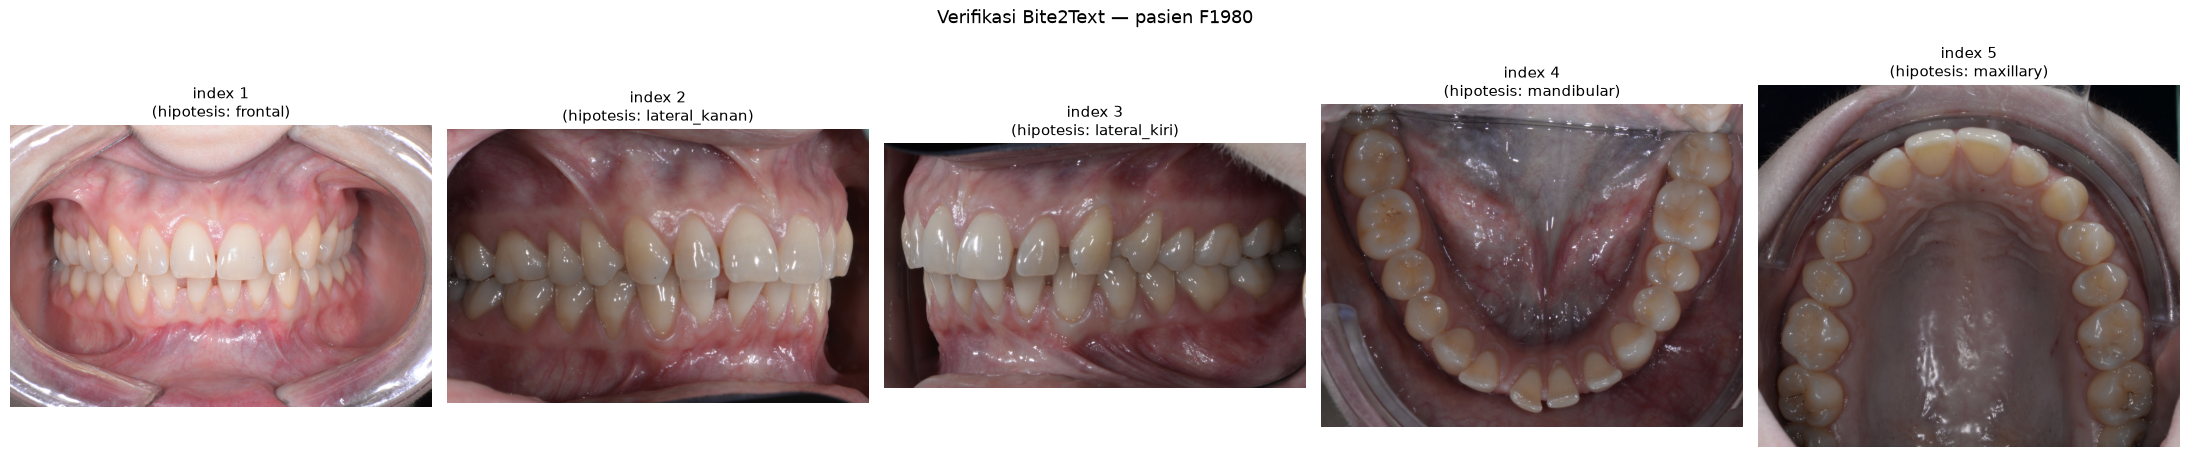

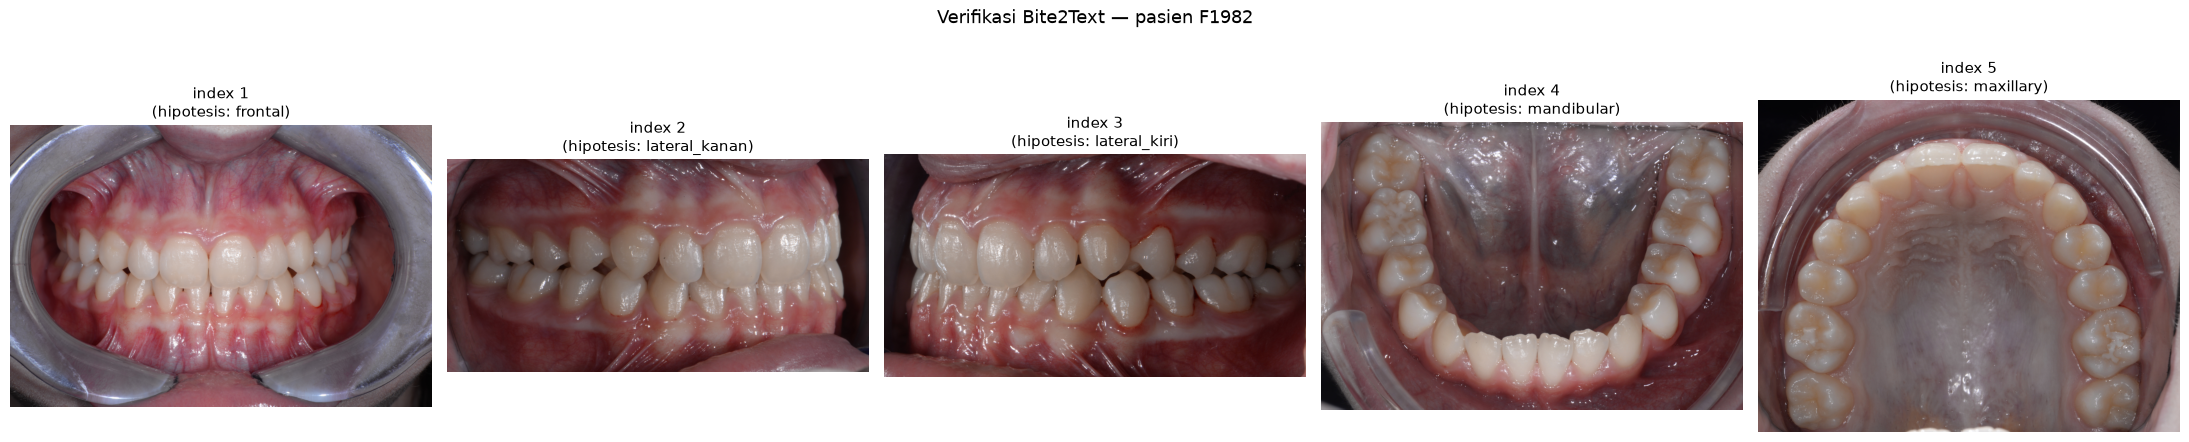


Cek visual satu per satu terhadap hipotesis:
  index 1 -> harus FRONTAL, pakai retractor
  index 2 -> lateral satu sisi, TANPA retractor
  index 3 -> lateral sisi satunya, TANPA retractor
  index 4 -> OKLUSAL RAHANG BAWAH / mandibular, lewat mirror (lidah biasanya kelihatan)
  index 5 -> OKLUSAL RAHANG ATAS / maxillary, lewat mirror

Kalau index 2/3 (kanan/kiri) ternyata kebalik, ubah INDEX_MAP di sel setup lalu jalankan ulang dari sini.


In [3]:
def tampilkan_verifikasi(pasien_id):
    files = foto_lengkap(pasien_id)
    if files is None:
        print(f'{pasien_id}: tidak lengkap 5 foto, dilewati'); return
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    for ax, kode in zip(axes, sorted(files)):
        img = Image.open(files[kode]).convert('RGB')
        ax.imshow(img)
        ax.set_title(f'index {kode}\n(hipotesis: {INDEX_MAP[kode]})', fontsize=11)
        ax.axis('off')
    fig.suptitle(f'Verifikasi Bite2Text — pasien {pasien_id}', fontsize=13)
    plt.tight_layout(); plt.show()

# ganti pilih_ke / daftar pasien di bawah kalau mau cek contoh lain
contoh_pasien = [p for p in PASIEN_SEMUA if foto_lengkap(p) is not None][:3]
for pid in contoh_pasien:
    tampilkan_verifikasi(pid)

print('\nCek visual satu per satu terhadap hipotesis:')
print('  index 1 -> harus FRONTAL, pakai retractor')
print('  index 2 -> lateral satu sisi, TANPA retractor')
print('  index 3 -> lateral sisi satunya, TANPA retractor')
print('  index 4 -> OKLUSAL RAHANG BAWAH / mandibular, lewat mirror (lidah biasanya kelihatan)')
print('  index 5 -> OKLUSAL RAHANG ATAS / maxillary, lewat mirror')
print('\nKalau index 2/3 (kanan/kiri) ternyata kebalik, ubah INDEX_MAP di sel setup lalu jalankan ulang dari sini.')

## 2. Filter folder yang lengkap 5 foto standar

In [4]:
PASIEN_LENGKAP = [p for p in PASIEN_SEMUA if foto_lengkap(p) is not None]
PASIEN_BOLONG = [p for p in PASIEN_SEMUA if foto_lengkap(p) is None]

print(f'Lengkap 5 foto : {len(PASIEN_LENGKAP)}')
print(f'Tidak lengkap  : {len(PASIEN_BOLONG)} (dilewati, tidak dipakai)')
if PASIEN_BOLONG:
    print('  contoh pasien bolong:', PASIEN_BOLONG[:10])

Lengkap 5 foto : 920
Tidak lengkap  : 77 (dilewati, tidak dipakai)
  contoh pasien bolong: ['F1981', 'F2179', 'F2180', 'F2181', 'F2184', 'F2185', 'F2187', 'F2188', 'F2189', 'F4648']


## 3. Split per pasien (50/25/25, seed tetap) lalu copy ke `data/view5/`

Split dari xlsx OMNI yang sudah ada **tidak diubah** — ini murni menambah pasien baru dari
Bite2Text ke split masing-masing. Porsi val/test sengaja dibesarkan dari biasanya (bukan
70/15/15) karena foto lateral tanpa-retractor di sini paling berharga sebagai **data evaluasi**
asli untuk fix retractor-bug, bukan cuma tambahan training.

In [5]:
def split_pasien(pasien_list, rasio=SPLIT_RATIO, seed=SEED):
    acak = list(pasien_list)
    random.Random(seed).shuffle(acak)
    n = len(acak)
    n_train = int(n * rasio['train'])
    n_val = int(n * rasio['val'])
    return {
        **{p: 'train' for p in acak[:n_train]},
        **{p: 'val' for p in acak[n_train:n_train + n_val]},
        **{p: 'test' for p in acak[n_train + n_val:]},
    }

PASIEN_SPLIT = split_pasien(PASIEN_LENGKAP)
cnt = Counter(PASIEN_SPLIT.values())
print('Jumlah pasien per split:', dict(cnt))

Jumlah pasien per split: {'train': 460, 'val': 230, 'test': 230}


In [6]:
def salin_bite2text(dry_run=False):
    """Salin foto ke data/view5/{split}/{view}/bite2text_{pasien_id}_{index}.jpg.
    dry_run=True: cuma hitung, tidak menyalin (cek dulu sebelum eksekusi asli)."""
    ringkasan = {s: Counter() for s in SPLITS}
    for pasien_id, split in PASIEN_SPLIT.items():
        files = foto_lengkap(pasien_id)
        for kode, nama_view in INDEX_MAP.items():
            src = files[kode]
            dst_dir = os.path.join(OUT_DIR, split, nama_view)
            dst_nama = f'{PREFIX}_{pasien_id}_{kode}.jpg'
            dst = os.path.join(dst_dir, dst_nama)
            if not dry_run:
                os.makedirs(dst_dir, exist_ok=True)
                shutil.copy2(src, dst)
            ringkasan[split][nama_view] += 1
    return ringkasan

# dry run dulu -- cek angkanya sebelum benar-benar menyalin
RINGKASAN = salin_bite2text(dry_run=True)
print(f'{"split":6s} ' + ' '.join(f'{v:>14s}' for v in INDEX_MAP.values()))
print('-' * 80)
for s in SPLITS:
    baris = ' '.join(f'{RINGKASAN[s][v]:>14d}' for v in INDEX_MAP.values())
    print(f'{s:6s} {baris}')
print('\nKalau angkanya sudah masuk akal, jalankan sel berikut dengan dry_run=False untuk benar-benar menyalin file.')

split         frontal  lateral_kanan   lateral_kiri     mandibular      maxillary
--------------------------------------------------------------------------------
train             460            460            460            460            460
val               230            230            230            230            230
test              230            230            230            230            230

Kalau angkanya sudah masuk akal, jalankan sel berikut dengan dry_run=False untuk benar-benar menyalin file.


In [7]:
# --- EKSEKUSI ASLI: salin file ke data/view5/ ---
RINGKASAN = salin_bite2text(dry_run=False)
total = sum(sum(RINGKASAN[s].values()) for s in SPLITS)
print(f'Selesai menyalin {total} foto Bite2Text ke {OUT_DIR}')
for s in SPLITS:
    print(f'  {s}: ' + ', '.join(f'{v}={RINGKASAN[s][v]}' for v in INDEX_MAP.values()))

Selesai menyalin 4600 foto Bite2Text ke /Users/rdrusdiati/IOTN-AC/data/view5
  train: frontal=460, lateral_kanan=460, lateral_kiri=460, mandibular=460, maxillary=460
  val: frontal=230, lateral_kanan=230, lateral_kiri=230, mandibular=230, maxillary=230
  test: frontal=230, lateral_kanan=230, lateral_kiri=230, mandibular=230, maxillary=230


---
## Langkah selanjutnya

1. **Pastikan bagian 1 sudah dicek visual dan `INDEX_MAP` sudah benar** sebelum eksekusi asli
   di atas (kalau sudah terlanjur salin dengan mapping salah, hapus isi `data/view5/*/lateral_*`
   yang berprefix `bite2text_` lalu ulangi dari bagian 3 dengan `INDEX_MAP` yang benar).
2. Jalankan ulang notebook **17** (retrain classifier — sekarang datanya gabungan OMNI +
   Bite2Text, jadi retractor-invariance augmentation dari sebelumnya + data asli tanpa-retractor
   di sini saling melengkapi).
3. Jalankan ulang notebook **18** (rebuild OOD config dari classifier yang baru).
4. Jalankan ulang notebook **20** (re-export Core ML) lalu copy `ViewValidator.mlpackage` +
   `ViewValidator_config.json` yang baru ke `Malokit/MLModels/`.